In [101]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from nltk import tokenize
import os
import asyncpg
from dotenv import load_dotenv
from urllib.parse import urlparse, parse_qs, urlencode, urlunparse
from tqdm import tqdm
import numpy as np
import pandas as pd

load_dotenv('../processing/.env')

# Ensure python (*.py) files are reloaded correctly while editing them
%load_ext autoreload
%autoreload 2


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Vader code examples

In [2]:
analyzer = SentimentIntensityAnalyzer()

# --- examples -------
sentences = ["VADER is smart, handsome, and funny.",  # positive sentence example
             "VADER is smart, handsome, and funny!",  # punctuation emphasis handled correctly (sentiment intensity adjusted)
             "VADER is very smart, handsome, and funny.", # booster words handled correctly (sentiment intensity adjusted)
             "VADER is VERY SMART, handsome, and FUNNY.",  # emphasis for ALLCAPS handled
             "VADER is VERY SMART, handsome, and FUNNY!!!", # combination of signals - VADER appropriately adjusts intensity
             "VADER is VERY SMART, uber handsome, and FRIGGIN FUNNY!!!", # booster words & punctuation make this close to ceiling for score
             "VADER is not smart, handsome, nor funny.",  # negation sentence example
             "The book was good.",  # positive sentence
             "At least it isn't a horrible book.",  # negated negative sentence with contraction
             "The book was only kind of good.", # qualified positive sentence is handled correctly (intensity adjusted)
             "The plot was good, but the characters are uncompelling and the dialog is not great.", # mixed negation sentence
             "Today SUX!",  # negative slang with capitalization emphasis
             "Today only kinda sux! But I'll get by, lol", # mixed sentiment example with slang and constrastive conjunction "but"
             "Make sure you :) or :D today!",  # emoticons handled
             "Catch utf-8 emoji such as such as 💘 and 💋 and 😁",  # emojis handled
             "Not bad at all"  # Capitalized negation
             ]

analyzer = SentimentIntensityAnalyzer()
for sentence in sentences:
    vs = analyzer.polarity_scores(sentence)
    print("{:-<65} {}".format(sentence, str(vs)))




VADER is smart, handsome, and funny.----------------------------- {'neg': 0.0, 'neu': 0.254, 'pos': 0.746, 'compound': 0.8316}
VADER is smart, handsome, and funny!----------------------------- {'neg': 0.0, 'neu': 0.248, 'pos': 0.752, 'compound': 0.8439}
VADER is very smart, handsome, and funny.------------------------ {'neg': 0.0, 'neu': 0.299, 'pos': 0.701, 'compound': 0.8545}
VADER is VERY SMART, handsome, and FUNNY.------------------------ {'neg': 0.0, 'neu': 0.246, 'pos': 0.754, 'compound': 0.9227}
VADER is VERY SMART, handsome, and FUNNY!!!---------------------- {'neg': 0.0, 'neu': 0.233, 'pos': 0.767, 'compound': 0.9342}
VADER is VERY SMART, uber handsome, and FRIGGIN FUNNY!!!--------- {'neg': 0.0, 'neu': 0.294, 'pos': 0.706, 'compound': 0.9469}
VADER is not smart, handsome, nor funny.------------------------- {'neg': 0.646, 'neu': 0.354, 'pos': 0.0, 'compound': -0.7424}
The book was good.----------------------------------------------- {'neg': 0.0, 'neu': 0.508, 'pos': 0.492, 'co

In [3]:
paragraph = ". ".join(sentences)

# use nltk to split paragraph into sentences

sentence_list = tokenize.sent_tokenize(paragraph)
for i, sentence in enumerate(sentence_list):
    print(i, sentence)

0 VADER is smart, handsome, and funny.. VADER is smart, handsome, and funny!.
1 VADER is very smart, handsome, and funny.. VADER is VERY SMART, handsome, and FUNNY.. VADER is VERY SMART, handsome, and FUNNY!!!.
2 VADER is VERY SMART, uber handsome, and FRIGGIN FUNNY!!!.
3 VADER is not smart, handsome, nor funny..
4 The book was good.. At least it isn't a horrible book..
5 The book was only kind of good..
6 The plot was good, but the characters are uncompelling and the dialog is not great.. Today SUX!.
7 Today only kinda sux!
8 But I'll get by, lol.
9 Make sure you :) or :D today!.
10 Catch utf-8 emoji such as such as 💘 and 💋 and 😁.
11 Not bad at all


Connect to db

In [160]:
DATABASE_URL = os.getenv('DATABASE_URL')
if (DATABASE_URL is None):
    raise ValueError("DATABASE_URL is not set in environment variables")


def remove_schema_param(url):
    """Remove the schema parameter from DATABASE_URL for asyncpg"""
    parsed = urlparse(url)
    query_params = parse_qs(parsed.query)

    # Remove 'schema' parameter if it exists
    query_params.pop('schema', None)

    # Rebuild the URL without schema parameter
    new_query = urlencode(query_params, doseq=True)
    new_parsed = parsed._replace(query=new_query)
    return urlunparse(new_parsed)


## Use regular SQL
# Remove schema parameter for asyncpg
asyncpg_url = remove_schema_param(DATABASE_URL)
conn = await asyncpg.connect(dsn=asyncpg_url)
comment_count = await conn.fetchval('SELECT COUNT(*) FROM "Comment";')
print(f'Comment count with SQL: {comment_count}')



Comment count with SQL: 627111


Create Comments table

In [5]:
# get column metadata for public."Comment"
schema_q = """
SELECT a.attnum AS ordinal_position,
    a.attname AS column_name,
    format_type(a.atttypid, a.atttypmod) AS data_type,
    NOT a.attnotnull AS is_nullable,
    pg_get_expr(ad.adbin, ad.adrelid) AS column_default
FROM pg_attribute a
LEFT JOIN pg_attrdef ad ON a.attrelid = ad.adrelid AND a.attnum = ad.adnum
WHERE a.attrelid = 'public."Comment"'::regclass
  AND a.attnum > 0
  AND NOT a.attisdropped
ORDER BY a.attnum;
"""
cols = await conn.fetch(schema_q)
if not cols:
    raise ValueError('Table public."Comment" not found or has no columns')

# schema as DataFrame
comment_schema = pd.DataFrame([dict(c) for c in cols])

# fetch all rows and convert to DataFrame
rows = await conn.fetch('SELECT * FROM "Comment";')
comment_df = pd.DataFrame([dict(r) for r in rows])
print(f'Loaded {len(comment_df)} rows into comment_df')
comment_df.head()


Loaded 627111 rows into comment_df


,id,body,userAddress,replyAddress,parentEntityType,parentEntityID,reactionCount,reportCount,createdAt,updatedAt,scrapedAt,parentCommentID
0,138810,Gn y'all,0xfd185f9439ac193541ad453a67b7ed21178ae165,None,Event,903193,1,0,2024-08-23 02:51:49.842,2025-11-18 01:06:08.238,2025-11-05 04:11:07.213,138809
1,138819,kys,0x6dd7275c0ba78b86bb5eaaa38d85be90979ce5ac,None,Event,903193,1,0,2024-08-23 02:52:18.992,2025-11-18 01:06:08.311,2025-11-05 04:11:07.322,138809
2,140037,"Honestly, this is the best poll there is. Trum...",0x827ffb096a98a9cd610604733b5614a87c911488,None,Event,903193,2,0,2024-08-23 05:54:31.914,2025-11-18 01:06:08.324,2025-11-05 04:11:07.415,None
3,140066,Really half of Trump supporters don’t use soci...,0x009c4fcc9253cc24ebf4fe6cf7dfb64875848f72,0xf8259a3c098bada205d2a4b7e26feb46bff8a075,Event,903193,1,0,2024-08-23 06:02:29.738,2025-11-18 01:06:08.406,2025-11-05 04:11:07.625,140037
4,140067,Have you seen Kamala voters? They are blue hai...,0x827ffb096a98a9cd610604733b5614a87c911488,0x1c064223623f73e96ebd85740d4bd41347038e70,Event,903193,1,0,2024-08-23 06:02:31.211,2025-11-18 01:06:08.418,2025-11-05 04:11:07.635,140037


Create Events table

In [ ]:
# get column metadata for public."Event"
event_schema_q = """
SELECT a.attnum AS ordinal_position,
  a.attname AS column_name,
  format_type(a.atttypid, a.atttypmod) AS data_type,
  NOT a.attnotnull AS is_nullable,
  pg_get_expr(ad.adbin, ad.adrelid) AS column_default
FROM pg_attribute a
LEFT JOIN pg_attrdef ad ON a.attrelid = ad.adrelid AND a.attnum = ad.adnum
WHERE a.attrelid = 'public."Event"'::regclass
  AND a.attnum > 0
  AND NOT a.attisdropped
ORDER BY a.attnum;
"""
event_cols = await conn.fetch(event_schema_q)
if not event_cols:
  raise ValueError('Table public."Event" not found or has no columns')

# schema as DataFrame
event_schema = pd.DataFrame([dict(c) for c in event_cols])

# fetch all rows and convert to DataFrame
event_rows = await conn.fetch('SELECT * FROM "Event";')
event_df = pd.DataFrame([dict(r) for r in event_rows])
print(f'Loaded {len(event_df)} rows into event_df')
event_df.head()


Loaded 65056 rows into event_df


,id,ticker,slug,title,description,resolutionSource,startDate,creationDate,endDate,closedTime,...,totalsMainLine,carouselMap,deployingTimestamp,scheduledDeploymentTimestamp,gameStatus,negRisk,negRiskMarketID,negRiskFeeBips,scrapedAt,createdInDb
0,27802,solana-up-or-down-june-21-7am-et,solana-up-or-down-june-21-7am-et,"Solana Up or Down - June 21, 7AM ET","This market will resolve to ""Up"" if the close ...",https://www.binance.com/en/trade/SOL_USDT,2025-06-19T15:48:21.773572Z,2025-06-19T15:48:21.773569Z,2025-06-21T12:00:00Z,2025-06-21 14:05:38,...,NaN,None,NaT,None,None,False,None,NaN,2025-11-04 21:41:31.131,2025-11-04 21:41:31.131
1,27803,solana-up-or-down-june-21-6pm-et,solana-up-or-down-june-21-6pm-et,"Solana Up or Down - June 21, 6PM ET","This market will resolve to ""Up"" if the close ...",https://www.binance.com/en/trade/SOL_USDT,2025-06-19T16:00:32.595637Z,2025-06-19T16:00:32.595634Z,2025-06-21T23:00:00Z,2025-06-22 01:02:23,...,NaN,None,NaT,None,None,False,None,NaN,2025-11-04 21:41:31.215,2025-11-04 21:41:31.215
2,27804,solana-up-or-down-june-21-10pm-et,solana-up-or-down-june-21-10pm-et,"Solana Up or Down - June 21, 10PM ET","This market will resolve to ""Up"" if the close ...",https://www.binance.com/en/trade/SOL_USDT,2025-06-19T16:00:32.602737Z,2025-06-19T16:00:32.602735Z,2025-06-22T03:00:00Z,2025-06-22 05:07:41,...,NaN,None,NaT,None,None,False,None,NaN,2025-11-04 21:41:31.241,2025-11-04 21:41:31.241
3,27805,solana-up-or-down-june-21-12am-et,solana-up-or-down-june-21-12am-et,"Solana Up or Down - June 21, 12AM ET","This market will resolve to ""Up"" if the close ...",https://www.binance.com/en/trade/SOL_USDT,2025-06-19T15:44:24.152932Z,2025-06-19T15:44:24.152929Z,2025-06-21T05:00:00Z,2025-06-21 07:04:11,...,NaN,None,NaT,None,None,False,None,NaN,2025-11-04 21:41:31.319,2025-11-04 21:41:31.319
4,27806,solana-up-or-down-june-21-3am-et,solana-up-or-down-june-21-3am-et,"Solana Up or Down - June 21, 3AM ET","This market will resolve to ""Up"" if the close ...",https://www.binance.com/en/trade/SOL_USDT,2025-06-19T15:46:24.571384Z,2025-06-19T15:46:24.571381Z,2025-06-21T08:00:00Z,2025-06-21 10:03:52,...,NaN,None,NaT,None,None,False,None,NaN,2025-11-04 21:41:31.405,2025-11-04 21:41:31.405


count     9280.000000
mean        67.576616
std        956.985524
min          1.000000
25%          2.000000
50%          8.000000
75%         26.000000
max      78010.000000
dtype: float64
Event ID with max comments: 903193 (78010 comments)


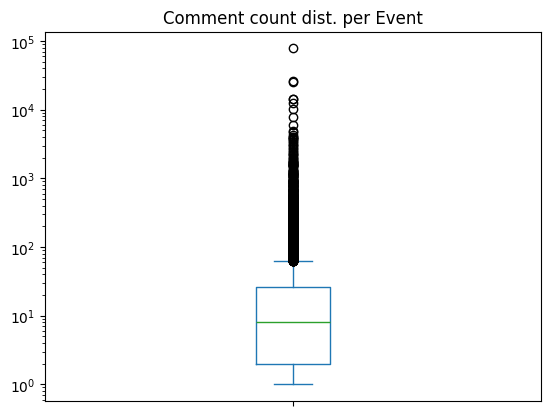

In [23]:
event_ids = comment_df['parentEntityID'].unique()

comment_count_per_event = comment_df.groupby('parentEntityID').size()
# show it on log scale
comment_count_per_event.plot(kind='box', title='Comment count dist. per Event', logy=True)
print(comment_count_per_event.describe())

# get the index with the max comments
max_comments_event_id = comment_count_per_event.idxmax()
print(f'Event ID with max comments: {max_comments_event_id} ({comment_count_per_event[max_comments_event_id]} comments)')

#add comment count per event to event_df
event_df = event_df.set_index('id')
event_df['commentCount'] = comment_count_per_event
event_df = event_df.reset_index()

In [8]:
analyzer = SentimentIntensityAnalyzer()

def score_comment_sentiment(comment):
    sentences = tokenize.sent_tokenize(comment)
    sentiments = [analyzer.polarity_scores(s)['compound'] for s in sentences]
    return np.mean(sentiments)

# test it on a subset of the comments first
# test_comments = comment_df.head(10).copy()
# test_comments['sentiment_score'] = tqdm(test_comments['body'].apply(score_comment_sentiment))
# display(test_comments)

# apply sentiment scoring to all comments
comment_df['sentiment_score'] = tqdm(comment_df['body'].apply(score_comment_sentiment))
comment_df.head()

 26%|██▌       | 161984/627111 [00:00<00:00, 1618695.34it/s]0.00s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.00s - to python to disable frozen modules.
0.00s - Note: Debugging will proceed. Set PYDEVD_DISABLE_FILE_VALIDATION=1 to disable this validation.
100%|██████████| 627111/627111 [00:00<00:00, 1889037.68it/s]


,id,body,userAddress,replyAddress,parentEntityType,parentEntityID,reactionCount,reportCount,createdAt,updatedAt,scrapedAt,parentCommentID,sentiment_score
0,138810,Gn y'all,0xfd185f9439ac193541ad453a67b7ed21178ae165,None,Event,903193,1,0,2024-08-23 02:51:49.842,2025-11-18 01:06:08.238,2025-11-05 04:11:07.213,138809,0.296000
1,138819,kys,0x6dd7275c0ba78b86bb5eaaa38d85be90979ce5ac,None,Event,903193,1,0,2024-08-23 02:52:18.992,2025-11-18 01:06:08.311,2025-11-05 04:11:07.322,138809,0.000000
2,140037,"Honestly, this is the best poll there is. Trum...",0x827ffb096a98a9cd610604733b5614a87c911488,None,Event,903193,2,0,2024-08-23 05:54:31.914,2025-11-18 01:06:08.324,2025-11-05 04:11:07.415,None,0.420267
3,140066,Really half of Trump supporters don’t use soci...,0x009c4fcc9253cc24ebf4fe6cf7dfb64875848f72,0xf8259a3c098bada205d2a4b7e26feb46bff8a075,Event,903193,1,0,2024-08-23 06:02:29.738,2025-11-18 01:06:08.406,2025-11-05 04:11:07.625,140037,0.181725
4,140067,Have you seen Kamala voters? They are blue hai...,0x827ffb096a98a9cd610604733b5614a87c911488,0x1c064223623f73e96ebd85740d4bd41347038e70,Event,903193,1,0,2024-08-23 06:02:31.211,2025-11-18 01:06:08.418,2025-11-05 04:11:07.635,140037,0.088950


In [9]:
# calcualte average sentiment per event
event_sentiment = comment_df.groupby('parentEntityID')['sentiment_score'].mean()
# add to event_df
event_df = event_df.set_index('id')
event_df['avg_comment_sentiment'] = event_sentiment
event_df = event_df.reset_index()
event_df.head()


,id,ticker,slug,title,description,resolutionSource,startDate,creationDate,endDate,closedTime,...,carouselMap,deployingTimestamp,scheduledDeploymentTimestamp,gameStatus,negRisk,negRiskMarketID,negRiskFeeBips,scrapedAt,createdInDb,avg_comment_sentiment
0,27802,solana-up-or-down-june-21-7am-et,solana-up-or-down-june-21-7am-et,"Solana Up or Down - June 21, 7AM ET","This market will resolve to ""Up"" if the close ...",https://www.binance.com/en/trade/SOL_USDT,2025-06-19T15:48:21.773572Z,2025-06-19T15:48:21.773569Z,2025-06-21T12:00:00Z,2025-06-21 14:05:38,...,None,NaT,None,None,False,None,NaN,2025-11-04 21:41:31.131,2025-11-04 21:41:31.131,NaN
1,27803,solana-up-or-down-june-21-6pm-et,solana-up-or-down-june-21-6pm-et,"Solana Up or Down - June 21, 6PM ET","This market will resolve to ""Up"" if the close ...",https://www.binance.com/en/trade/SOL_USDT,2025-06-19T16:00:32.595637Z,2025-06-19T16:00:32.595634Z,2025-06-21T23:00:00Z,2025-06-22 01:02:23,...,None,NaT,None,None,False,None,NaN,2025-11-04 21:41:31.215,2025-11-04 21:41:31.215,NaN
2,27804,solana-up-or-down-june-21-10pm-et,solana-up-or-down-june-21-10pm-et,"Solana Up or Down - June 21, 10PM ET","This market will resolve to ""Up"" if the close ...",https://www.binance.com/en/trade/SOL_USDT,2025-06-19T16:00:32.602737Z,2025-06-19T16:00:32.602735Z,2025-06-22T03:00:00Z,2025-06-22 05:07:41,...,None,NaT,None,None,False,None,NaN,2025-11-04 21:41:31.241,2025-11-04 21:41:31.241,NaN
3,27805,solana-up-or-down-june-21-12am-et,solana-up-or-down-june-21-12am-et,"Solana Up or Down - June 21, 12AM ET","This market will resolve to ""Up"" if the close ...",https://www.binance.com/en/trade/SOL_USDT,2025-06-19T15:44:24.152932Z,2025-06-19T15:44:24.152929Z,2025-06-21T05:00:00Z,2025-06-21 07:04:11,...,None,NaT,None,None,False,None,NaN,2025-11-04 21:41:31.319,2025-11-04 21:41:31.319,NaN
4,27806,solana-up-or-down-june-21-3am-et,solana-up-or-down-june-21-3am-et,"Solana Up or Down - June 21, 3AM ET","This market will resolve to ""Up"" if the close ...",https://www.binance.com/en/trade/SOL_USDT,2025-06-19T15:46:24.571384Z,2025-06-19T15:46:24.571381Z,2025-06-21T08:00:00Z,2025-06-21 10:03:52,...,None,NaT,None,None,False,None,NaN,2025-11-04 21:41:31.405,2025-11-04 21:41:31.405,NaN


In [10]:
# count rows where sentiment_score is NaN
nan_sentiment_count = event_df['avg_comment_sentiment'].isna().sum()
print(f'Number of comments with NaN sentiment score: {nan_sentiment_count}')

# drop rows with NaN sentiment score
event_df = event_df.dropna(subset=['avg_comment_sentiment'])
event_df.shape

Number of comments with NaN sentiment score: 55776


(9280, 77)

<Axes: title={'center': 'Distribution of Average Comment Sentiment per Event'}, ylabel='Frequency'>

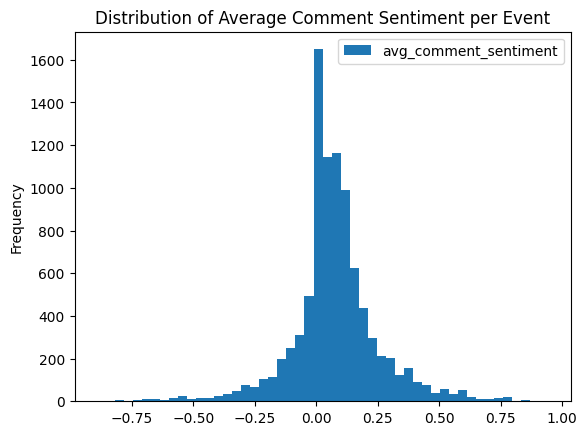

In [11]:
event_df.plot(kind='hist', y='avg_comment_sentiment', bins=50, title='Distribution of Average Comment Sentiment per Event')

In [14]:
event_df['avg_comment_sentiment'].describe()

count    9280.000000
mean        0.073313
std         0.180104
min        -0.891000
25%         0.000000
50%         0.062478
75%         0.144466
max         0.942700
Name: avg_comment_sentiment, dtype: float64

In [16]:
comment_df.to_parquet('comment_sentiment.parquet', index=False)
event_df.to_parquet('event_sentiment.parquet', index=False)

In [46]:
closed_events = event_df[event_df['closed'] == True]
closed_events.shape

valid_events = closed_events[closed_events['commentCount'] > 33]
valid_events.shape

(1761, 77)

In [47]:
valid_event_ids = valid_events['id'].tolist()

# convert ids to strings to form ('10016', '10017', ...)
valid_event_ids_str = "', '".join([str(eid) for eid in valid_event_ids])
valid_event_ids_str = f"('{valid_event_ids_str}')"
print(valid_event_ids_str)

('27841', '28173', '28201', '28206', '28215', '28219', '28223', '28384', '28444', '28445', '28457', '28596', '28598', '28601', '28625', '28634', '28637', '28642', '28644', '28651', '28652', '28655', '28656', '28660', '28780', '28817', '28822', '28832', '28978', '28998', '29012', '30074', '30358', '30359', '30389', '30435', '30446', '30466', '30631', '31104', '31113', '31132', '31164', '31186', '31226', '31231', '31345', '31354', '31355', '31381', '31382', '31384', '31406', '31531', '31575', '31741', '31742', '31747', '31876', '31877', '31884', '31912', '31913', '32206', '32217', '32227', '32284', '32289', '32420', '32434', '32438', '32536', '32548', '32563', '32569', '32586', '32765', '32776', '32779', '32928', '32931', '32949', '32953', '33239', '33282', '33466', '33321', '33324', '33485', '33504', '33520', '33646', '33664', '33667', '33669', '33692', '33698', '33807', '33829', '33830', '33832', '33866', '33991', '33992', '34040', '34041', '34342', '34350', '34351', '34576', '34580', 

In [65]:

get_markets_sql = f"""
SELECT em."A" as "event_id", m.*
FROM "public"."Market" m
INNER JOIN "public"."_EventToMarket" em ON m."id" = em."B"
WHERE em."A" IN {valid_event_ids_str};
"""
markets = await conn.fetch(get_markets_sql)
market_df = pd.DataFrame([dict(m) for m in markets])

# join 'avg_comment_sentiment' from valid_events to market_df based on event_id
market_df = market_df.merge(valid_events[['id', 'avg_comment_sentiment']], left_on='event_id', right_on='id', how='left')
market_df.drop(columns=['id_y'], inplace=True)
market_df.rename(columns={'id_x': 'id'}, inplace=True)
# filter market_df to only rows where outcomes is a 2 element list


In [ ]:
# cast outcomes and outcomePrices to lists
market_df['outcomes'] = market_df['outcomes'].apply(lambda x: eval(x))
market_df['outcomePrices'] = market_df['outcomePrices'].apply(lambda x: eval(x))
market_df = market_df[market_df['outcomes'].apply(lambda x: len(x)== 2)]
market_df['label'] = market_df['outcomePrices'].apply(lambda prices: 1 if prices[0] > prices[1] else 0)

In [147]:
market_df['event_id'].nunique()

1761

In [ ]:
# check how many events in event_df have multiple markets that have different labels (1 and 0)
market_event_label_counts = market_df.groupby('event_id')['label'].nunique()
conflicting_events = market_event_label_counts[market_event_label_counts > 1]
print(f'Number of events with conflicting market labels: {len(conflicting_events)}')

markets_per_event = market_df.groupby('event_id').size()
print(markets_per_event.describe())


def get_event_label(event_id):
    event_markets = market_df[market_df['event_id'] == event_id]

    if event_markets.empty:
        return None
    
    event_markets.loc[:, 'volume'] = pd.to_numeric(event_markets['volume'], errors='coerce').fillna(0)
    
    max_volume_market = event_markets.loc[event_markets['volume'].idxmax()]
    return max_volume_market['label']

valid_events.loc[:, 'label'] = valid_events['id'].apply(get_event_label)
valid_events.shape

Number of events with conflicting market labels: 813
count    1761.000000
mean        6.113004
std         7.423875
min         1.000000
25%         1.000000
50%         1.000000
75%        10.000000
max        68.000000
dtype: float64


(1761, 78)

In [165]:
get_valid_comments_sql = f"""
SELECT c.*
FROM "public"."Comment" c
WHERE c."parentEntityID" IN {valid_event_ids_str};
"""

comments = await conn.fetch(get_valid_comments_sql)
valid_comment_df = pd.DataFrame([dict(c) for c in comments])
valid_comment_df.shape

(530848, 12)

In [166]:
valid_comment_df = valid_comment_df.merge(valid_events[['id', 'label']], left_on='parentEntityID', right_on='id', how='left')
valid_comment_df.drop(columns=['id_y'], inplace=True)
valid_comment_df.rename(columns={'id_x': 'id'}, inplace=True)
valid_comment_df.head() 

,id,body,userAddress,replyAddress,parentEntityType,parentEntityID,reactionCount,reportCount,createdAt,updatedAt,scrapedAt,parentCommentID,label
0,138810,Gn y'all,0xfd185f9439ac193541ad453a67b7ed21178ae165,None,Event,903193,1,0,2024-08-23 02:51:49.842,2025-11-18 01:06:08.238,2025-11-05 04:11:07.213,138809,1
1,138819,kys,0x6dd7275c0ba78b86bb5eaaa38d85be90979ce5ac,None,Event,903193,1,0,2024-08-23 02:52:18.992,2025-11-18 01:06:08.311,2025-11-05 04:11:07.322,138809,1
2,140037,"Honestly, this is the best poll there is. Trum...",0x827ffb096a98a9cd610604733b5614a87c911488,None,Event,903193,2,0,2024-08-23 05:54:31.914,2025-11-18 01:06:08.324,2025-11-05 04:11:07.415,None,1
3,140066,Really half of Trump supporters don’t use soci...,0x009c4fcc9253cc24ebf4fe6cf7dfb64875848f72,0xf8259a3c098bada205d2a4b7e26feb46bff8a075,Event,903193,1,0,2024-08-23 06:02:29.738,2025-11-18 01:06:08.406,2025-11-05 04:11:07.625,140037,1
4,140067,Have you seen Kamala voters? They are blue hai...,0x827ffb096a98a9cd610604733b5614a87c911488,0x1c064223623f73e96ebd85740d4bd41347038e70,Event,903193,1,0,2024-08-23 06:02:31.211,2025-11-18 01:06:08.418,2025-11-05 04:11:07.635,140037,1


In [167]:
valid_comment_df['label'].value_counts()

label
1    267695
0    263153
Name: count, dtype: int64

In [168]:
valid_comment_df.to_parquet('valid_comment_sentiment.parquet', index=False)

# Evaluating predictive power of sentiment score 

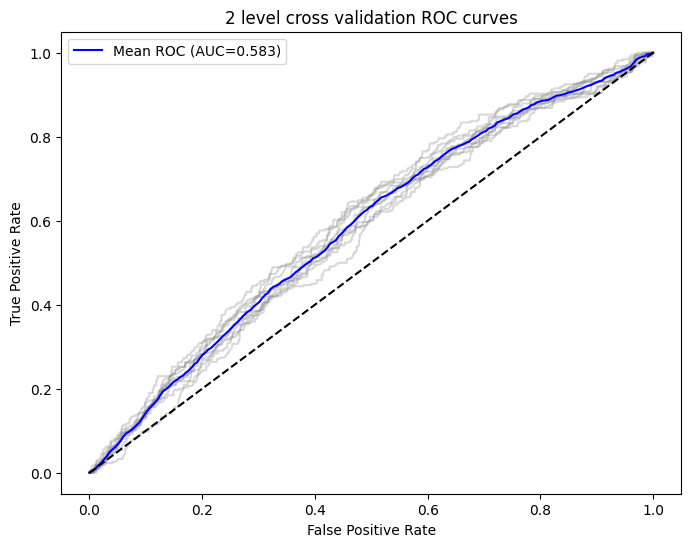

Optimal thresholds per outer fold:
[np.float64(0.30460786577586657), np.float64(0.2724053308997889), np.float64(0.2772490194906546), np.float64(0.28217600754819244), np.float64(0.28094027351422185), np.float64(0.2891899545382657), np.float64(0.2835494677529456), np.float64(0.2869282433221131), np.float64(0.28852731486766076), np.float64(0.2669793001578173)]

Mean optimal threshold: 0.28325527778675264


In [134]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_curve, auc

X = market_df[['avg_comment_sentiment']]
y = market_df['label']

# Pipeline: scaling + logistic regression
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('logreg', LogisticRegression())
])

# Outer and inner folds
outer_cv = KFold(n_splits=10, shuffle=True, random_state=42)
inner_cv = KFold(n_splits=5, shuffle=True, random_state=42)

mean_fpr = np.linspace(0, 1, 200)

tprs = []
aucs = []
opt_thresholds = []

plt.figure(figsize=(8, 6))

# ------------------------
# OUTER LOOP
# ------------------------
for fold_idx, (train_idx, test_idx) in enumerate(outer_cv.split(X, y)):

    X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
    X_test,  y_test  = X.iloc[test_idx],  y.iloc[test_idx]

    # ----------------------------------------
    # INNER LOOP: Select optimal threshold
    # ----------------------------------------
    best_thresh = None
    best_j = -np.inf

    for inner_train, inner_val in inner_cv.split(X_train, y_train):
        pipeline.fit(X_train.iloc[inner_train], y_train.iloc[inner_train])
        y_val_probs = pipeline.predict_proba(X_train.iloc[inner_val])[:, 1]

        fpr, tpr, thresholds = roc_curve(y_train.iloc[inner_val], y_val_probs)

        # Youden J = sensitivity + specificity - 1
        J = tpr - fpr
        idx = np.argmax(J)

        if J[idx] > best_j:
            best_j = J[idx]
            best_thresh = thresholds[idx]

    opt_thresholds.append(best_thresh)

    # ----------------------------------------
    # Train final model on full outer training fold
    # ----------------------------------------
    pipeline.fit(X_train, y_train)
    y_probs = pipeline.predict_proba(X_test)[:, 1]

    # ROC for this fold
    fpr, tpr, _ = roc_curve(y_test, y_probs)
    aucs.append(auc(fpr, tpr))

    # Interpolated TPR for mean ROC curve
    tpr_interp = np.interp(mean_fpr, fpr, tpr)
    tpr_interp[0] = 0.0
    tprs.append(tpr_interp)

    # Plot this fold
    plt.plot(fpr, tpr, color='gray', alpha=0.3)

# ------------------------
# MEAN ROC CURVE
# ------------------------
mean_tpr = np.mean(tprs, axis=0)
mean_auc = auc(mean_fpr, mean_tpr)

plt.plot(mean_fpr, mean_tpr, color='blue', label=f"Mean ROC (AUC={mean_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle='--', color='black')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("2 level cross validation ROC curves")
plt.legend()
plt.show()

# ------------------------
# OUTPUT RESULTS
# ------------------------
print("Optimal thresholds per outer fold:")
print(opt_thresholds)
print("\nMean optimal threshold:", np.mean(opt_thresholds))